# Support Vector Machines — From Intuition to Kernels

## 1. Linear Classification Refresher

Before understanding **Support Vector Machines**, let's recall the idea of a **linear classifier**.

A linear classifier separates two classes using a straight line (in 2D) or a **hyperplane** (in higher dimensions).

The classifier is defined as:

$$
f(x) = w \cdot x + b
$$

Where:

- $x$ is the **feature vector**
- $w$ is the **weight vector**
- $b$ is the **bias**

The **decision boundary** occurs when:

$$
w \cdot x + b = 0
$$

Predictions are made using the sign function:

$$
y = \text{sign}(w \cdot x + b)
$$

If the result is **positive** → class $1$  
If the result is **negative** → class $-1$


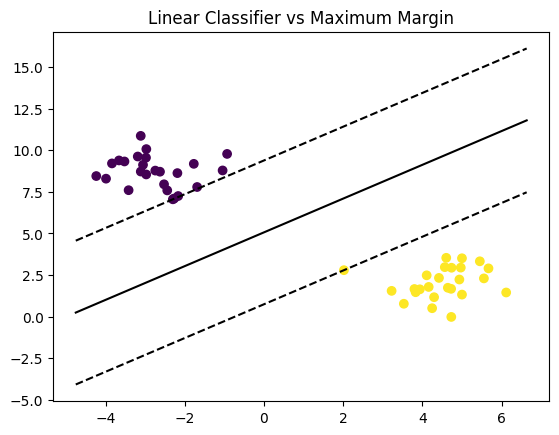

In [10]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=50, centers=2, random_state=42)
model = SVC(kernel="linear", C=1000)  # Hard margin
model.fit(X, y)

plt.scatter(X[:,0], X[:,1], c=y)
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Plot margin lines
import numpy as np
w = model.coef_[0]
b = model.intercept_[0]
xx = np.linspace(xlim[0], xlim[1], 30)
yy = - (w[0]/w[1]) * xx - b/w[1]
yy_down = yy - 1/w[1]
yy_up = yy + 1/w[1]

plt.plot(xx, yy, 'k-')
plt.plot(xx, yy_down, 'k--')
plt.plot(xx, yy_up, 'k--')
plt.title("Linear Classifier vs Maximum Margin")
plt.show()


## 2. Maximum Margin Intuition

Many lines can separate two classes.  
**Support Vector Machines** choose the one that **maximizes the margin**.

The **margin** is the distance between the decision boundary and the closest data points.

### Why maximize the margin?

- Better **generalization**
- More **robust to noise**
- More **stable predictions**

The margin boundaries are:

$$
w \cdot x + b = 1
$$

and

$$
w \cdot x + b = -1
$$

The margin width equals:

$$
\frac{2}{\|w\|}
$$

SVM tries to **maximize this margin**.

---

## 3. Hard Margin Support Vector Machine

In the ideal case, the data is **perfectly separable**.

We enforce the constraint:

$$
y_i (w \cdot x_i + b) \geq 1
$$

The optimization objective becomes:

$$
\min_{w,b} \frac{1}{2}\|w\|^2
$$

Minimizing $\|w\|^2$ is equivalent to **maximizing the margin**.

However, **perfectly separable data is rare in practice**.

---

## 4. Soft Margin Support Vector Machine

Real-world datasets often contain:

- **noise**
- **outliers**
- **overlapping classes**

Therefore, SVM introduces **slack variables** $\xi_i$ to allow margin violations.

The optimization becomes:

$$
\min_{w,b,\xi} \frac{1}{2}\|w\|^2 + C \sum_{i=1}^{n} \xi_i
$$

subject to:

$$
y_i (w \cdot x_i + b) \geq 1 - \xi_i
$$

$$
\xi_i \geq 0
$$

Where:

- $\xi_i$ measures **margin violations**
- $C$ controls the **penalty for misclassification**

Interpretation of $C$:

- **Large $C$** → fewer misclassifications, smaller margin
- **Small $C$** → wider margin, more tolerance for errors

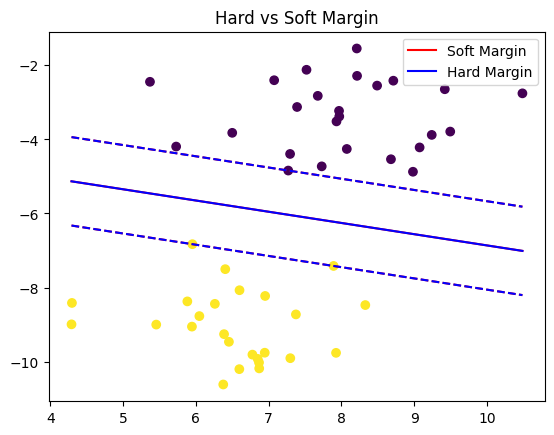

In [11]:
X, y = make_blobs(n_samples=50, centers=2, random_state=6)
# Soft margin
model_soft = SVC(kernel="linear", C=1)
model_soft.fit(X, y)

# Hard margin (almost impossible with noisy data)
model_hard = SVC(kernel="linear", C=1e6)
model_hard.fit(X, y)

plt.scatter(X[:,0], X[:,1], c=y)
xx = np.linspace(X[:,0].min(), X[:,0].max(), 30)

def plot_margin(model, color, label):
    w = model.coef_[0]
    b = model.intercept_[0]
    yy = - (w[0]/w[1]) * xx - b/w[1]
    yy_down = yy - 1/w[1]
    yy_up = yy + 1/w[1]
    plt.plot(xx, yy, color, label=label)
    plt.plot(xx, yy_down, color+'--')
    plt.plot(xx, yy_up, color+'--')

plot_margin(model_soft, 'r', 'Soft Margin')
plot_margin(model_hard, 'b', 'Hard Margin')
plt.legend()
plt.title("Hard vs Soft Margin")
plt.show()


In [1]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Generate synthetic dataset
X, y = make_classification(
    n_samples=500,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    random_state=42,
    class_sep=1.5
)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [2]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

params = {"C":[0.01,0.1,1,10,100]}

grid = GridSearchCV(SVC(kernel="linear"), params, cv=5)
grid.fit(X_train, y_train)

print(grid.best_params_)


{'C': 0.01}


## 5. What Are Support Vectors?

**Support vectors** are the data points closest to the **margin boundaries**.  

These points **determine the position of the decision boundary**.

Interestingly:

- Removing most data points does **not** change the boundary  
- Removing **support vectors** changes the classifier

The decision function can be written as:

$$
f(x) = \sum_{i \in SV} \alpha_i y_i (x_i \cdot x) + b
$$

Where:

- $SV$ are the **support vectors**  
- $\alpha_i$ are the **learned coefficients**

In [3]:
model = SVC(kernel="linear")
model.fit(X_train, y_train)

print(model.support_vectors_)


[[ 0.44500979  2.60133166]
 [-0.06069283  2.47646075]
 [-0.31634177 -0.79126642]
 [ 0.00653875 -0.23118489]
 [-0.71703081  2.02781401]
 [-0.23699454  2.33876428]
 [-0.15245405 -0.38058836]
 [-0.36802148 -0.50629561]
 [-0.16739454 -0.58176727]
 [ 0.33941579  2.70481662]
 [ 0.39257626  2.57794949]
 [ 0.55164386  2.75545315]
 [-0.03673808  2.44404923]
 [-0.45383165 -0.65617152]
 [-0.43457521 -0.63203603]
 [-0.40413131 -0.63703844]
 [ 0.70824798  2.86298774]
 [ 0.91126876  0.46648648]
 [-0.74195018  2.07423275]
 [-0.25923074 -0.59443059]
 [-0.47467827  2.22550775]
 [-0.03845665  2.43567348]
 [-0.24532244 -0.45004667]
 [-0.2867158  -0.52859413]
 [-0.13281251 -0.46563498]
 [ 0.11530149 -0.17735168]
 [ 0.26712796 -1.20767115]
 [-0.07193175  2.70315917]
 [ 0.12040956  1.11777391]
 [ 0.49946128 -1.90426119]
 [ 0.291004   -1.30532487]
 [ 0.14427006  2.91735586]
 [-1.41236793  2.45441922]
 [ 0.13447024  0.35728943]
 [-0.39636216  0.96083106]
 [ 0.11723941 -1.10823551]
 [ 0.47578263 -1.14122599]
 

## 6. When Linear Boundaries Fail

Some datasets **cannot be separated by a straight line**.

**Example: medicine dosage effectiveness**

- Too little dosage → ineffective  
- Optimal dosage → effective  
- Too high dosage → harmful  

This relationship can look like:

$$
y = x^2
$$

A **linear classifier** cannot separate these classes.  

We need a **nonlinear decision boundary** to handle such problems.

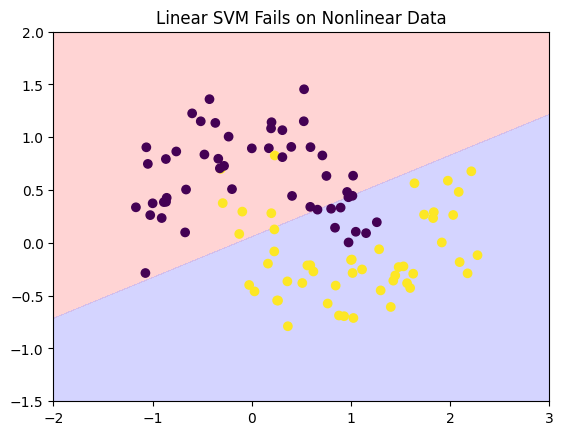

In [12]:
from sklearn.datasets import make_moons

X, y = make_moons(noise=0.2)
model_linear = SVC(kernel="linear", C=1)
model_linear.fit(X, y)

xx, yy = np.meshgrid(np.linspace(-2, 3, 500), np.linspace(-1.5, 2, 500))
Z = model_linear.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, levels=[Z.min(), 0, Z.max()], colors=['#FFAAAA','#AAAAFF'], alpha=0.5)
plt.scatter(X[:,0], X[:,1], c=y)
plt.title("Linear SVM Fails on Nonlinear Data")
plt.show()


## 7. Feature Transformation

One solution is to **transform the data into a higher-dimensional space**.

**Example transformation:**

$$
x \rightarrow (x, x^2)
$$

Now the classifier becomes:

$$
w_1 x + w_2 x^2 + b = 0
$$

In this new space, the problem may become **linearly separable**.

However, explicitly computing many transformations can be **computationally expensive**.

This observation leads to the **Kernel Trick**, which allows us to compute the effect of these transformations **implicitly**.

## 8. Kernel Trick

Instead of computing transformations explicitly, SVM uses **kernel functions**.

A kernel computes the **similarity between two points**:

$$
K(x_i, x_j) = \phi(x_i) \cdot \phi(x_j)
$$

Where $\phi(x)$ is the **hidden feature transformation**.

This allows SVM to operate in **very high-dimensional spaces efficiently** without explicitly computing the transformed features.

## 9. Polynomial Kernel

One common kernel is the **polynomial kernel**.

$$
K(x_i, x_j) = (x_i \cdot x_j + r)^d
$$

Where:

- $d$ is the **degree** of the polynomial  
- $r$ is a **constant**

A higher value of $d$ allows **more complex decision boundaries**, enabling the SVM to capture more intricate patterns in the data.

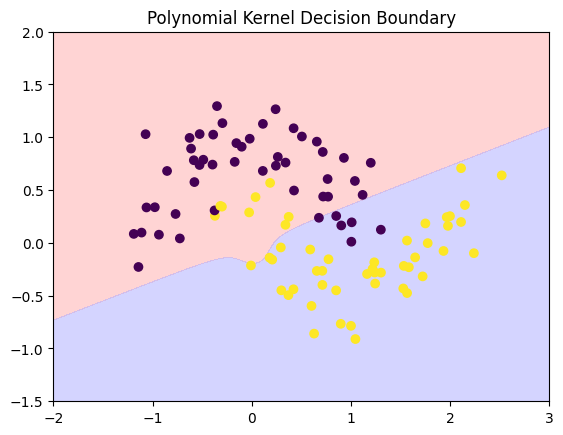

In [13]:
X, y = make_moons(noise=0.2)
model_poly = SVC(kernel="poly", degree=3, C=1)
model_poly.fit(X, y)

xx, yy = np.meshgrid(np.linspace(-2, 3, 500), np.linspace(-1.5, 2, 500))
Z = model_poly.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, levels=[Z.min(), 0, Z.max()], colors=['#FFAAAA','#AAAAFF'], alpha=0.5)
plt.scatter(X[:,0], X[:,1], c=y)
plt.title("Polynomial Kernel Decision Boundary")
plt.show()


In [4]:
model = SVC(kernel="poly", degree=3, C=1)
model.fit(X_train, y_train)


SVC(C=1, kernel='poly')

In [5]:
params = {
    "degree":[2,3,4],
    "C":[0.1,1,10]
}

grid = GridSearchCV(SVC(kernel="poly"), params, cv=5)
grid.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=SVC(kernel='poly'),
             param_grid={'C': [0.1, 1, 10], 'degree': [2, 3, 4]})

## 10. Radial Basis Function (RBF) Kernel

The most popular kernel in practice is the **Radial Basis Function (RBF) kernel**.

$$
K(x_i, x_j) = e^{-\gamma \|x_i - x_j\|^2}
$$

Where:

- $\gamma$ controls the **influence of nearby points**  
- **Small $\gamma$** → smoother, simpler decision boundary  
- **Large $\gamma$** → more complex, wiggly decision boundary

In [6]:
model = SVC(kernel="rbf", gamma=0.1, C=1)
model.fit(X_train, y_train)


SVC(C=1, gamma=0.1)

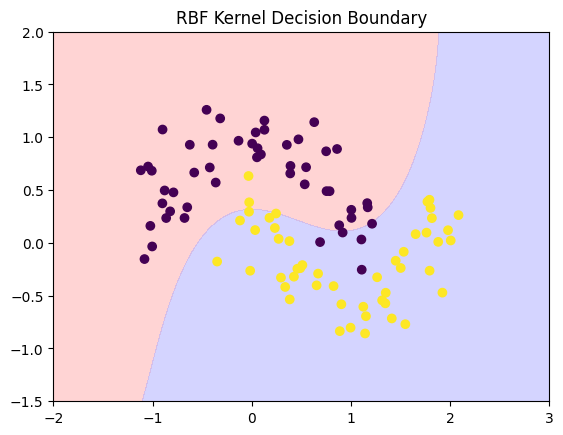

In [14]:
X, y = make_moons(noise=0.2)
model_rbf = SVC(kernel="rbf", gamma=0.5, C=1)
model_rbf.fit(X, y)

xx, yy = np.meshgrid(np.linspace(-2, 3, 500), np.linspace(-1.5, 2, 500))
Z = model_rbf.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, levels=[Z.min(), 0, Z.max()], colors=['#FFAAAA','#AAAAFF'], alpha=0.5)
plt.scatter(X[:,0], X[:,1], c=y)
plt.title("RBF Kernel Decision Boundary")
plt.show()


## 11. Infinite Dimensional Feature Space

The **RBF kernel** corresponds to mapping data into an **infinite-dimensional feature space**.  

Even though this sounds computationally impossible, the **kernel trick** allows us to compute:

$$
K(x_i, x_j) = \phi(x_i) \cdot \phi(x_j)
$$

without explicitly computing $\phi(x)$.

---

## 12. Connection to Taylor Series

The exponential function can be written as a **Taylor expansion**:

$$
e^z = \sum_{k=0}^{\infty} \frac{z^k}{k!}
$$

Substituting

$$
z = -\gamma \|x_i - x_j\|^2
$$

shows that the **RBF kernel combines infinitely many polynomial features**, effectively mapping the data into an **infinite-dimensional space**.

---

## 13. Final SVM Decision Function

The final classifier depends **only on support vectors**:

$$
f(x) = \sum_{i=1}^{n} \alpha_i y_i K(x_i, x) + b
$$

This means the classifier is determined by:

- **Support vectors**  
- **Kernel similarity** between points

# Advanced topics
## 14. Dual Optimization Problem of SVM

The **primal optimization problem** for the soft-margin SVM is:

$$
\min_{w,b,\xi} \frac{1}{2}\|w\|^2 + C \sum_{i=1}^{n} \xi_i
$$

subject to:

$$
y_i (w \cdot x_i + b) \geq 1 - \xi_i, \quad \xi_i \geq 0
$$

Instead of solving this directly, SVM uses the **dual formulation**:

$$
\max_{\alpha} \sum_{i=1}^{n} \alpha_i - \frac{1}{2} \sum_{i=1}^{n} \sum_{j=1}^{n} \alpha_i \alpha_j y_i y_j (x_i \cdot x_j)
$$

subject to:

$$
0 \leq \alpha_i \leq C, \quad \sum_{i=1}^{n} \alpha_i y_i = 0
$$

Where:

- $\alpha_i$ are **Lagrange multipliers**  
- Only points with $\alpha_i > 0$ are **support vectors**

The **dual problem** allows us to:

- Introduce **kernels easily**  
- Solve SVM in **higher-dimensional spaces efficiently**

---

## 15. Geometric Interpretation of Kernels

Kernels map **low-dimensional data** to a **higher-dimensional space**.

**Example: Polynomial kernel**

$$
K(x_i, x_j) = (x_i \cdot x_j + r)^d
$$

- In 2D space, the decision boundary may be **nonlinear**  
- In 3D (or higher), the boundary becomes a **linear hyperplane**  

The kernel computes the **dot product in high-dimensional space** without explicitly mapping:

$$
\phi(x_i) \cdot \phi(x_j) = K(x_i, x_j)
$$

This is the **kernel trick**.

---

## 16. Why Only Support Vectors Matter

The **decision function** depends only on support vectors:

$$
f(x) = \sum_{i \in SV} \alpha_i y_i K(x_i, x) + b
$$

- Points **far from the margin** have $\alpha_i = 0$  
- They **do not influence the decision boundary**

This is why SVM is **robust** and **sparse**.